In [ ]:
import pickle

with open("eval_summary_table.pkl", "rb") as f:
    table = pickle.load(f)

import pandas as pd

df = pd.DataFrame(table.data, columns=table.columns)

assert df['prompt'].nunique() == 279, f"Expected 279 unique prompts, got {df['prompt'].nunique()}"
grouped_df = df.groupby('prompt').agg({
    'code': list,
    'full_response': list,
    'reward': list
}).reset_index()

from transformers import AutoTokenizer

# Load the "Qwen/qwen3-0.6b" tokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/qwen3-0.6b")

# Helper function to count tokens in a string (handles None gracefully)
def count_tokens(text):
    if text is None:
        return 0
    # Tokenize and count tokens.
    return len(tokenizer.encode(text))

# Add new columns to grouped_df - compute length in tokens
grouped_df['code_length_tokens'] = grouped_df['code'].apply(
    lambda codes: [count_tokens(code) for code in codes if code is not None]
)
grouped_df['full_response_length_tokens'] = grouped_df['full_response'].apply(
    lambda responses: [count_tokens(resp) for resp in responses]
)

In [ ]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots


idx = 50
# Filter rows where the sum of the reward column is greater than 0
filtered_grouped_df = grouped_df[grouped_df['reward'].apply(lambda rewards: sum(rewards) > 0)].iloc[idx:idx+1]

# Plot 1: One subplot per row for code_length_tokens (mark reward==1)
num_prompts = len(filtered_grouped_df)
fig_code = make_subplots(
    rows=num_prompts, 
    cols=1, 
    shared_xaxes=False
)

for i, (idx, row) in enumerate(filtered_grouped_df.iterrows()):
    codes = row['code']
    code_lengths = row['code_length_tokens']
    rewards = row['reward']

    # x-axis: indices in code_lengths
    x_vals = []
    code_lengths_filtered = []
    reward_1_x = []
    reward_1_y = []

    code_index = 0
    for j, code in enumerate(codes):
        if code is not None:
            x_vals.append(j)
            code_length = code_lengths[code_index]
            code_lengths_filtered.append(code_length)
            if rewards[j] == 1:
                reward_1_x.append(j)
                reward_1_y.append(code_length)
            code_index += 1
        # if code is None, nothing is appended, and code_index is not incremented

    # Main line for non-None codes in their original positions
    fig_code.add_trace(
        go.Scatter(
            x=x_vals,
            y=code_lengths_filtered,
            mode='lines',
            showlegend=False
        ),
        row=i+1, col=1
    )

    # Markers for reward==1, only for non-None codes
    if reward_1_x:
        fig_code.add_trace(
            go.Scatter(
                x=reward_1_x,
                y=reward_1_y,
                mode='markers',
                marker=dict(color='red', size=8, symbol='circle'),
                showlegend=False
            ),
            row=i+1, col=1
        )

fig_code.update_layout(
    height=min(250 * num_prompts, 4000),
    width=900,
    showlegend=False
)

fig_code.show()

# Plot 2: One subplot per row for full_response_length_tokens (mark reward==1)
fig_resp = make_subplots(
    rows=num_prompts, 
    cols=1, 
    shared_xaxes=False
)

for i, (idx, row) in enumerate(filtered_grouped_df.iterrows()):
    full_responses = row['full_response']
    response_lengths = row['full_response_length_tokens']
    rewards = row['reward']

    # x-axis: indices in response_lengths (responses that are not None)
    x_vals = []
    response_lengths_filtered = []
    reward_1_x = []
    reward_1_y = []

    resp_index = 0
    for j, resp in enumerate(full_responses):
        if resp is not None:
            x_vals.append(j)
            resp_len = response_lengths[resp_index]
            response_lengths_filtered.append(resp_len)
            if rewards[j] == 1:
                reward_1_x.append(j)
                reward_1_y.append(resp_len)
            resp_index += 1

    # Main line for non-None responses
    fig_resp.add_trace(
        go.Scatter(
            x=x_vals,
            y=response_lengths_filtered,
            mode='lines',
            showlegend=False
        ),
        row=i+1, col=1
    )

    # Markers for reward==1, only for non-None responses
    if reward_1_x:
        fig_resp.add_trace(
            go.Scatter(
                x=reward_1_x,
                y=reward_1_y,
                mode='markers',
                marker=dict(color='red', size=8, symbol='circle'),
                showlegend=False
            ),
            row=i+1, col=1
        )

fig_resp.update_layout(
    height=min(250 * num_prompts, 4000),
    width=900,
    showlegend=False
)

fig_resp.show()

In [ ]:
prompt = filtered_grouped_df.iloc[0]['prompt']

max_tokens = 7998
codes = filtered_grouped_df.iloc[0]['code']
rewards = []
full_responses = []
for i, full_response_length_tokens in enumerate(filtered_grouped_df.iloc[0]['full_response_length_tokens']):
    if full_response_length_tokens < max_tokens and codes[i] is not None:
        reward = filtered_grouped_df.iloc[0]['reward'][i]
        rewards.append(reward)        
        full_responses.append(filtered_grouped_df.iloc[0]['full_response'][i])

code_lengths_tokens = filtered_grouped_df.iloc[0]['code_length_tokens']

print(prompt)

codes = [code for code in filtered_grouped_df.iloc[0]['code'] if code is not None]
code_lengths_tokens = filtered_grouped_df.iloc[0]['code_length_tokens']

for code, reward, code_len_tokens, full_response in zip(codes, rewards, code_lengths_tokens, full_responses):
    if code is not None:
        correctness = "correct" if reward == 1 else "incorrect"
        print(f"************************************** [len={code_len_tokens}] [{correctness}]\n{code}")

## Regular Consolidated Model Loading

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4,5,6,7"
import torch
from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer

BASE_MODEL_ID = "Qwen/Qwen3-0.6B"
CKPT_DIR = "/private/schwartz-lab/yarin_shaked7/SkyRL/checkpoints/global_step_85/policy"
CKPT_PATH = os.path.join(CKPT_DIR, "consolidated_model.pt")
HF_META_DIR = os.path.join(CKPT_DIR, "huggingface")
LORA_DIR = os.path.join(CKPT_DIR, "lora_adapter")

# 1. rebuild the base model with the exact config used during training
if os.path.exists(os.path.join(HF_META_DIR, "config.json")):
    config = AutoConfig.from_pretrained(HF_META_DIR)
else:
    config = AutoConfig.from_pretrained(BASE_MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    config=config,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)

# 2. re-attach LoRA adapter if it exists
if os.path.isdir(LORA_DIR):
    print("Loading LoRA adapter")
    from peft import PeftModel

    model = PeftModel.from_pretrained(model, LORA_DIR)

# 3. load the consolidated state dict
state_dict = torch.load(CKPT_PATH, map_location="cpu")
missing, unexpected = model.load_state_dict(state_dict, strict=True)
if missing or unexpected:
    raise ValueError(f"State dict mismatch. missing={missing}, unexpected={unexpected}")

# 4. move to inference device and switch to eval mode
model = model.to("cuda")
model.eval()

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)

## United lora+model Saving

In [ ]:
import os
import torch
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel


BASE_MODEL_ID = "Qwen/Qwen3-0.6B"
CKPT_DIR = "/private/schwartz-lab/yarin_shaked7/SkyRL/checkpoints/global_step_85/policy"
CKPT_PATH = os.path.join(CKPT_DIR, "consolidated_model.pt")
HF_META_DIR = os.path.join(CKPT_DIR, "huggingface")
HF_EXPORT_DIR = os.path.join(CKPT_DIR, "hf_export")
LORA_DIR = os.path.join(CKPT_DIR, "lora_adapter")

# 1. Rebuild the HF-style checkpoint (base + LoRA merged)
config = AutoConfig.from_pretrained(HF_META_DIR, local_files_only=True, trust_remote_code=True)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    config=config,
    dtype=torch.float16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

peft_model = PeftModel.from_pretrained(base_model, LORA_DIR, is_trainable=False)

state_dict = torch.load(CKPT_PATH, map_location="cpu")
peft_model.load_state_dict(state_dict, strict=True)

merged_model = peft_model.merge_and_unload()
merged_model.save_pretrained(HF_EXPORT_DIR)
config.save_pretrained(HF_EXPORT_DIR)

tokenizer = AutoTokenizer.from_pretrained(HF_META_DIR, local_files_only=True, trust_remote_code=True)
tokenizer.save_pretrained(HF_EXPORT_DIR)

print("Merged model + tokenizer exported to:", HF_EXPORT_DIR)

## Load United Model and Inference

In [1]:
%%capture

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "4,5,6,7"
from vllm import LLM, SamplingParams

CKPT_DIR = "/private/schwartz-lab/yarin_shaked7/SkyRL/checkpoints/global_step_85/policy"
HF_EXPORT_DIR = os.path.join(CKPT_DIR, "hf_export")

# 2. Fire up vLLM using the exported folder
llm = LLM(
    model=HF_EXPORT_DIR,
    tokenizer=HF_EXPORT_DIR,
    dtype="float16",
    tensor_parallel_size=4,   # adjust if you want fewer GPUs
    gpu_memory_utilization=0.45,
    trust_remote_code=True,
)
tokenizer = llm.get_tokenizer()

In [2]:
%%capture

og_llm = LLM(
    model="Qwen/Qwen3-0.6B",
    dtype="float16",
    tensor_parallel_size=4,   # adjust if you want fewer GPUs
    gpu_memory_utilization=0.45,
    trust_remote_code=True,
)

In [3]:
import datasets


def load_data(data_file_paths):
    loaded_datasets = []
    for source in data_file_paths:
        ds = datasets.load_dataset("json", data_files=source, keep_in_memory=True)["train"]
        loaded_datasets.append(ds)

    dataframe = datasets.concatenate_datasets(loaded_datasets)

    print(f"Total dataset size: {len(dataframe)}")

    return dataframe


DATA_DIR = "/private/schwartz-lab/yarin_shaked7/SkyRL/train_shards/deepcoder_train_part_000{file_num}.json"
data_file_paths = [DATA_DIR.format(file_num=i) for i in range(1, 5)]
dataframe = load_data(data_file_paths)


Total dataset size: 200


In [4]:
import re

def extract_code_from_model(model_response: str):
    code_blocks = re.findall(r"```(?:\w+)?\n(.*?)```", model_response, re.DOTALL)
    if not code_blocks:
        return None
    return code_blocks[-1].strip()

In [5]:
sampling_params = SamplingParams(temperature=0.7, max_tokens=8000, n=8)
prompts = dataframe['prompt']
input_ids = [tokenizer.apply_chat_template(prompt, add_generation_prompt=True, tokenize=False) for prompt in prompts]
outputs = llm.generate(input_ids, sampling_params)
og_outputs = llm.generate(input_ids, sampling_params)

Adding requests:  32%|███▎      | 65/200 [00:00<00:00, 643.11it/s]

Processed prompts: 100%|██████████| 1600/1600 [28:40<00:00,  1.08s/it, est. speed input: 484.36 toks/s, output: 4369.05 toks/s]


In [6]:
texts = [[o.text for o in output.outputs] for output in outputs]
code_blocks = [[extract_code_from_model(t) for t in text] for text in texts]


og_texts = [[o.text for o in output.outputs] for output in og_outputs]
og_code_blocks = [[extract_code_from_model(t) for t in text] for text in og_texts]

Average token length for code_blocks: 125.60
Average token length for og_code_blocks: 123.22


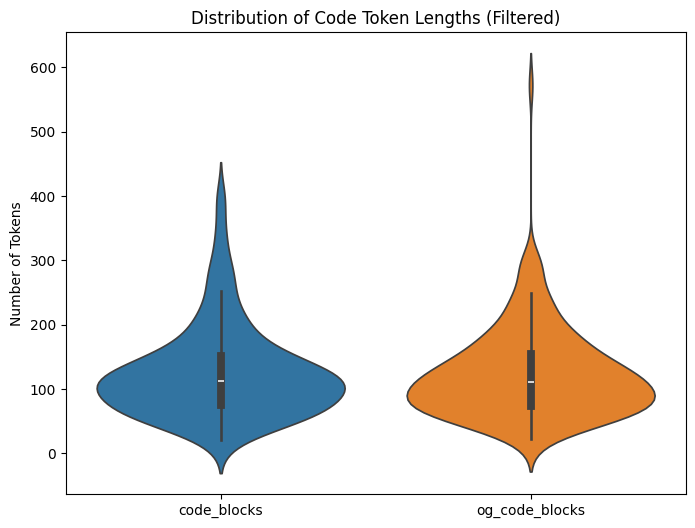

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter indices where either code_blocks or og_code_blocks have at least one non-None code block
valid_indices = [
    i for i, (codes, og_codes) in enumerate(zip(code_blocks, og_code_blocks))
    if (any(c is not None for c in codes) and any(c is not None for c in og_codes))
]

# Compute token lengths for filtered indices
code_lengths = [
    len(tokenizer.encode(next(c for c in code_blocks[i] if c is not None), add_special_tokens=False))
    for i in valid_indices
]
og_code_lengths = [
    len(tokenizer.encode(next(c for c in og_code_blocks[i] if c is not None), add_special_tokens=False))
    for i in valid_indices
]

# Calculate averages
avg_code_length = sum(code_lengths) / len(code_lengths) if code_lengths else 0
avg_og_code_length = sum(og_code_lengths) / len(og_code_lengths) if og_code_lengths else 0

print(f"Average token length for code_blocks: {avg_code_length:.2f}")
print(f"Average token length for og_code_blocks: {avg_og_code_length:.2f}")

# Prepare data for violin plot
data = [code_lengths, og_code_lengths]
labels = ['code_blocks', 'og_code_blocks']

plt.figure(figsize=(8, 6))
sns.violinplot(data=data)
plt.xticks([0, 1], labels)
plt.ylabel("Number of Tokens")
plt.title("Distribution of Code Token Lengths (Filtered)")
plt.show()


Average token length for texts: 4623.21
Average token length for og_texts: 4697.46


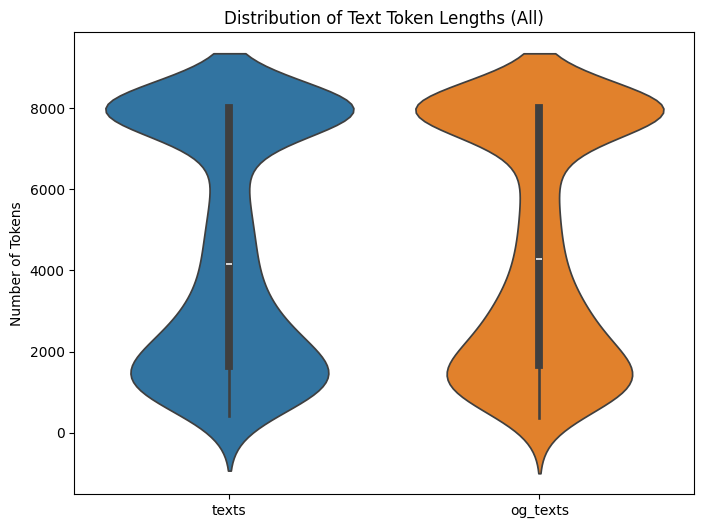

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute token lengths for all texts and og_texts (not just filtered indices), flattening inner list
text_lengths = [
    len(tokenizer.encode(text, add_special_tokens=False))
    for text_group in texts for text in text_group
]
og_text_lengths = [
    len(tokenizer.encode(text, add_special_tokens=False))
    for text_group in og_texts for text in text_group
]

# Calculate averages
avg_text_length = sum(text_lengths) / len(text_lengths) if text_lengths else 0
avg_og_text_length = sum(og_text_lengths) / len(og_text_lengths) if og_text_lengths else 0

print(f"Average token length for texts: {avg_text_length:.2f}")
print(f"Average token length for og_texts: {avg_og_text_length:.2f}")

# Prepare data for violin plot
data = [text_lengths, og_text_lengths]
labels = ['texts', 'og_texts']

plt.figure(figsize=(8, 6))
sns.violinplot(data=data)
plt.xticks([0, 1], labels)
plt.ylabel("Number of Tokens")
plt.title("Distribution of Text Token Lengths (All)")
plt.show()
